In [4]:
#1.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('Mall_Customers_Enhanced.csv')
print(df.dtypes)


CustomerID                  int64
Gender                     object
Age                         int64
Annual Income (k$)          int64
Spending Score (1-100)      int64
Age Group                  object
Estimated Savings (k$)    float64
Credit Score                int64
Loyalty Years               int64
Preferred Category         object
dtype: object


In [5]:
#data shape
df.shape

(200, 10)

In [6]:
#First 5 rows
print(df.head(5))

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

  Age Group  Estimated Savings (k$)  Credit Score  Loyalty Years  \
0     18-25                   11.10           456              3   
1     18-25                    6.90           300              6   
2     18-25                   15.36           594              2   
3     18-25                    7.79           300              6   
4     26-35                   12.47           480              5   

  Preferred Category  
0             Budget  
1             Luxury  
2             Budget  
3             Luxury  
4             Budget  


In [7]:
#Missing values
print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
Age Group                 4
Estimated Savings (k$)    0
Credit Score              0
Loyalty Years             0
Preferred Category        0
dtype: int64


In [8]:
#Duplicate records 
print(df[df.duplicated()])

Empty DataFrame
Columns: [CustomerID, Gender, Age, Annual Income (k$), Spending Score (1-100), Age Group, Estimated Savings (k$), Credit Score, Loyalty Years, Preferred Category]
Index: []


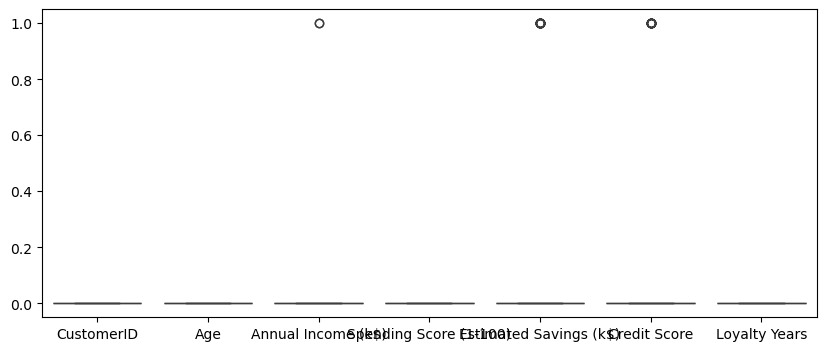

In [9]:
df1=df.select_dtypes(include=['int64','float64']).columns
Q1 = df[df1].quantile(0.25)
Q3 = df[df1].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outlier_count = ((df[df1] < lower) | (df[df1] > upper))
plt.figure(figsize=(10,4))
sns.boxplot(data=outlier_count,color='blue')
plt.show()


Outliers in Annual Income (k$): 2


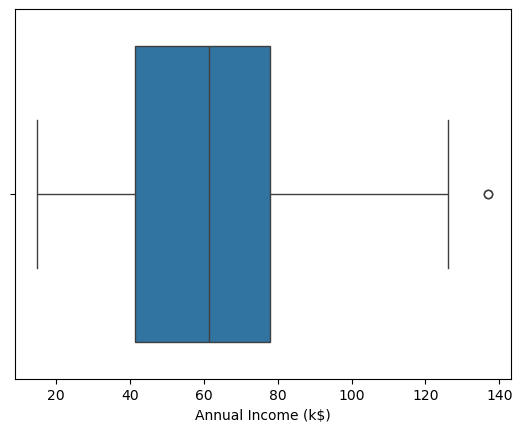

In [10]:
# Outliers (basic detection)
import seaborn as sns
df = pd.read_csv('Mall_Customers_Enhanced.csv')
col ='Annual Income (k$)'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
print(f"Outliers in {col}: {len(outliers)}")

sns.boxplot(x=df['Annual Income (k$)'])
plt.show()


In [46]:
#2.Handle missing values: 
import warnings
warnings.filterwarnings('ignore')
# Fill missing values with mode
df['Age Group'].fillna(df['Age Group'].mode(), inplace=True)


In [47]:
import warnings
warnings.filterwarnings('ignore')
#fill missing values with mean
df['Credit Score'].fillna(df['Credit Score'].mean(), inplace=True)

In [53]:
from sklearn.preprocessing import LabelEncoder

for col in ['Preferred Category']:
    df[col] = LabelEncoder().fit_transform(df[col])
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1       1   19                  15                      39   
1           2       1   21                  15                      81   
2           3       0   20                  16                       6   
3           4       0   23                  16                      77   
4           5       0   31                  17                      40   

   Age Group  Estimated Savings (k$)  Credit Score  Loyalty Years  \
0          0                   11.10           456              3   
1          0                    6.90           300              6   
2          0                   15.36           594              2   
3          0                    7.79           300              6   
4          1                   12.47           480              5   

   Preferred Category  
0                   0  
1                   3  
2                   0  
3                   3  
4                   

In [51]:
import pandas as pd
encoded_data = pd.get_dummies(df,columns=['Age Group','Gender'])
print(df.head)

<bound method NDFrame.head of      CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0             1       1   19                  15                      39   
1             2       1   21                  15                      81   
2             3       0   20                  16                       6   
3             4       0   23                  16                      77   
4             5       0   31                  17                      40   
..          ...     ...  ...                 ...                     ...   
195         196       0   35                 120                      79   
196         197       0   45                 126                      28   
197         198       1   32                 126                      74   
198         199       1   32                 137                      18   
199         200       1   30                 137                      83   

     Age Group  Estimated Savings (k$)  Credit Score  Loy

In [55]:
#apply  StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_columns = df.select_dtypes(include='number').columns

df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

print(df.head())

   CustomerID    Gender       Age  Annual Income (k$)  Spending Score (1-100)  \
0   -1.723412  1.128152 -1.424569           -1.738999               -0.434801   
1   -1.706091  1.128152 -1.281035           -1.738999                1.195704   
2   -1.688771 -0.886405 -1.352802           -1.700830               -1.715913   
3   -1.671450 -0.886405 -1.137502           -1.700830                1.040418   
4   -1.654129 -0.886405 -0.563369           -1.662660               -0.395980   

   Age Group  Estimated Savings (k$)  Credit Score  Loyalty Years  \
0  -1.401168               -1.369731     -1.858538      -1.869963   
1  -1.401168               -1.567099     -2.866367       0.044675   
2  -1.401168               -1.169544     -0.966998      -2.508176   
3  -1.401168               -1.525276     -2.866367       0.044675   
4  -0.567139               -1.305352     -1.703488      -0.593538   

   Preferred Category  
0           -1.572773  
1            1.357860  
2           -1.572773  
3 

In [15]:
#Select features: 
# Dependent variable
Y = df['Spending Score (1-100)'].values

# Independent variables
X = df['Age'].values


In [37]:
# Implement Linear Regression without using scikit-learn
import numpy as np
import pandas as pd

df = pd.read_csv("Mall_Customers_Enhanced.csv")

# Independent Variable
X = df['Annual Income (k$)'].values

# Dependent Variable
Y = df['Spending Score (1-100)'].values

# Parameters
b0 = 0
b1 = 0

alpha = 0.0001
epochs = 1000

n = len(Y)

# Cost Function
def compute_cost(Y, Y_pred):
    return np.mean((Y - Y_pred) ** 2)
# Gradient Descent
for i in range(epochs):

    Y_pred = b0 + b1 * X
    error = Y_pred - Y

    db0 = (2/n) * np.sum(error)
    db1 = (2/n) * np.sum(error * X)

    b0 = b0 - alpha * db0
    b1 = b1 - alpha * db1

    cost = compute_cost(Y, Y_pred)

    if i % 100 == 0:
        print(f"Epoch {i}, Cost = {cost}")

print("\nIntercept (b0):", b0)
print("Slope (b1):", b1)
print("Final Cost:", cost)

Epoch 0, Cost = 3183.56
Epoch 100, Cost = 1048.867944764111
Epoch 200, Cost = 1046.445627316863
Epoch 300, Cost = 1044.0385341137517
Epoch 400, Cost = 1041.6465694705348
Epoch 500, Cost = 1039.2696383043447
Epoch 600, Cost = 1036.907646129908
Epoch 700, Cost = 1034.5604990557922
Epoch 800, Cost = 1032.2281037806702
Epoch 900, Cost = 1029.910367589613

Intercept (b0): 1.5489598387126344
Slope (b1): 0.678264398422697
Final Cost: 1027.6301582374786


In [18]:
#Predict values for test data
import numpy as np
import pandas as pd

df = pd.read_csv("Mall_Customers_Enhanced.csv")

X = df['Annual Income (k$)'].values
Y = df['Spending Score (1-100)'].values

# 80% Train, 20% Test
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

Y_train = Y[:split]
Y_test = Y[split:]
# Predict on test data
Y_pred_test = b0 + b1 * X_test

print("Test Predictions:")
print(Y_pred_test[:10])
result = pd.DataFrame({'Actual': Y_test,'Predicted': Y_pred_test})

print(result.head(10))

Test Predictions:
[55.13184731 55.13184731 56.48837611 56.48837611 59.2014337  59.2014337
 59.8796981  59.8796981  60.5579625  60.5579625 ]
   Actual  Predicted
0      35  55.131847
1      83  55.131847
2       5  56.488376
3      93  56.488376
4      26  59.201434
5      75  59.201434
6      20  59.879698
7      95  59.879698
8      27  60.557963
9      63  60.557963


In [19]:
#. Calculate R² score manually
Y_pred = b0 + b1 * X
ss_res = np.sum((Y - Y_pred) ** 2)
ss_tot = np.sum((Y - np.mean(Y)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print("R² Score:", r2)

R² Score: -0.5487207595104973


In [30]:
#4: Linear Regression – Using Scikit-Learn 
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("Mall_Customers_Enhanced.csv")

X = df[['Annual Income (k$)']]
y = df['Spending Score (1-100)']

# 80% Train, 20% Test
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (160, 1)
X_test shape: (40, 1)
Y_train shape: (160,)
Y_test shape: (40,)


In [31]:
df.shape

(200, 10)

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Create Model
model = LinearRegression()

# Train Model
model.fit(X_train, Y_train)

# Predict Test Data
Y_pred = model.predict(X_test)

# Evaluation
r2 = r2_score(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)

print("R² Score:", r2)
print("Mean Squared Error:", mse)

R² Score: -0.02983794140128393
Mean Squared Error: 671.8244358038282


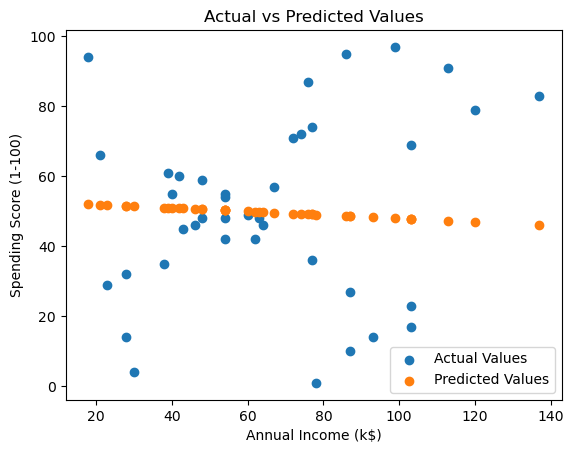

In [33]:
#5: Visualization
import matplotlib.pyplot as plt

plt.scatter(X_test, Y_test, label="Actual Values") 
plt.scatter(X_test, Y_pred, label="Predicted Values")

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Actual vs Predicted Values")
plt.legend()

plt.show()

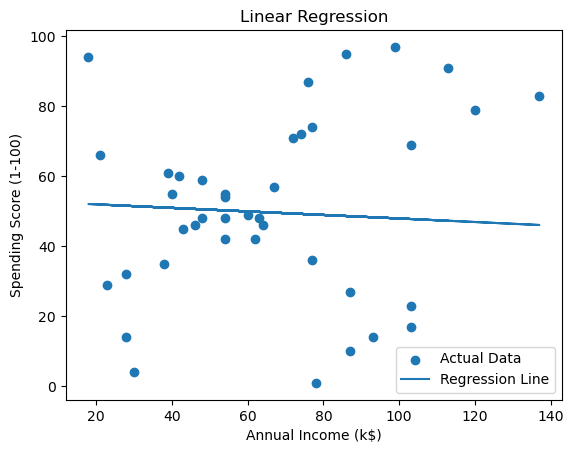

In [34]:
import matplotlib.pyplot as plt

plt.scatter(X_test, Y_test, label="Actual Data")

plt.plot(X_test, Y_pred, label="Regression Line")

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Linear Regression")
plt.legend()

plt.show()